# Ideal Livable Spots — Bucharest

A personalized, accessibility-based livability score over an H3 hex grid.

**Pipeline:** boundary → POIs → hex grid → assign POIs → distance-decayed catchment →
saturate → normalize → **personalized weighted score** → map.

> v1 uses a pure-H3 grid-ring decay (no pandana/routing needed, installs cleanly on any
> Python). Swap Step 5 for network travel-time decay (pandana / r5py) once the routing
> env is set up — the rest of the notebook stays identical.

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import h3
from shapely.geometry import Polygon
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import folium

ox.settings.use_cache = True 

## 1 · Area of interest

In [3]:
place = "Bucuresti, Romania"     # prototype small; swap to "Bucharest, Romania" later

g = ox.geocode_to_gdf(place)
print(g.geom_type.iloc[0], "—", g.iloc[0]["display_name"])
area = g.geometry.iloc[0]                 # reuse this geometry (no second geocode)
g.explore()

Polygon — Bucharest, Romania


## 2 · Pull POIs (one request per category, labelled)

In [4]:
tag_groups = {
    "education": {"amenity": ["school", "kindergarten", "university", "college", "library"]},
    "health":    {"amenity": ["hospital", "clinic", "pharmacy", "doctors"], "healthcare": True},
    "green":     {"leisure": ["park", "playground", "garden", "sports_centre", "fitness_centre"]},
    "groceries": {"shop": ["supermarket", "convenience", "bakery", "greengrocer"],
                  "amenity": ["marketplace"]},
    "transit":   {"railway": ["station", "subway_entrance", "tram_stop"], "highway": ["bus_stop"]},
    "culture":   {"amenity": ["cafe", "restaurant", "bar", "cinema", "theatre"],
                  "tourism": ["museum", "gallery"]},
    "services":  {"amenity": ["bank", "atm", "post_office"]},
}

def fetch(cat, tags):
    gg = ox.features_from_polygon(area, tags=tags)
    gg["poi_category"] = cat
    return gg.to_crs(4326)

frames = []
with ThreadPoolExecutor(max_workers=3) as ex:          # keep low — Overpass rate limits
    futures = {ex.submit(fetch, c, t): c for c, t in tag_groups.items()}
    for fut in as_completed(futures):
        cat = futures[fut]
        try:
            frames.append(fut.result())
        except Exception as e:
            print(f"{cat} failed: {e}")

pois = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=4326)
if "name" not in pois.columns:
    pois["name"] = None
pois["geometry"] = pois.geometry.representative_point()   # mixed pt/poly -> one point each
pois = pois[["poi_category", "name", "geometry"]]
print(len(pois), "POIs across", pois["poi_category"].nunique(), "categories")

12702 POIs across 7 categories


## 3 · Build the H3 hex grid (res 9)

2135 hexes


<Axes: >

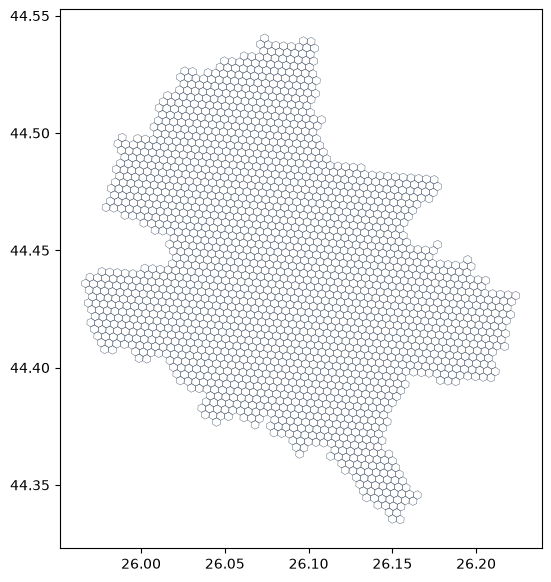

In [5]:
def make_hexgrid(boundary_gdf, res=9):
    aoi = boundary_gdf.to_crs(4326).union_all()
    cells = h3.geo_to_cells(aoi, res)
    poly = lambda c: Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(c)])
    return gpd.GeoDataFrame({"h3_index": list(cells)},
                            geometry=[poly(c) for c in cells], crs=4326)

grid = make_hexgrid(g, res=9)
print(len(grid), "hexes")
grid.boundary.plot(figsize=(7, 7), color="#475569", linewidth=0.3)

## 4 · Assign POIs to hexes (containment counts)

In [6]:
pois["h3_index"] = pois.geometry.map(lambda p: h3.latlng_to_cell(p.y, p.x, 9))

counts = (pois.groupby(["h3_index", "poi_category"]).size().unstack(fill_value=0))
counts = counts.reindex(grid["h3_index"], fill_value=0)     # align to grid, fill empties
categories = list(counts.columns)
print("categories:", categories)
counts.head()

categories: ['culture', 'education', 'green', 'groceries', 'health', 'services', 'transit']


poi_category,culture,education,green,groceries,health,services,transit
h3_index,,,,,,,
891eeeb4917ffff,0,0,0,0,0,0,0
891eec6b367ffff,0,0,0,0,0,0,0
891eeeb6ca7ffff,2,1,1,4,4,1,0
891eeeb4a73ffff,0,0,0,0,0,0,0
891eec6b4c3ffff,0,0,0,0,0,0,0


## 5 · Distance-decayed catchment (pure-H3 v1)

Each hex accrues value from POIs in nearby hexes, decaying with grid-ring distance — so a
pharmacy one hex over still counts. `K` rings ≈ K × 350 m.

*Later:* replace `grid_distance` with **network travel time** (pandana walk/bike, r5py
transit) for true accessibility. The output shape stays the same.

In [7]:
K, D0 = 3, 1.5                       # 3 rings (~1 km) catchment, decay scale
lookup = counts.to_dict("index")     # h3_index -> {category: count}
zero = {c: 0 for c in categories}

def catchment(cell):
    acc = {c: 0.0 for c in categories}
    for nb in h3.grid_disk(cell, K):
        try:
            d = h3.grid_distance(cell, nb)
        except Exception:
            continue
        w = np.exp(-d / D0)
        cn = lookup.get(nb, zero)
        for c in categories:
            acc[c] += w * cn[c]
    return acc

access = pd.DataFrame([catchment(c) for c in grid["h3_index"]])
print("hexes with access > 0:", (access.sum(axis=1) > 0).sum(), "of", len(grid))

hexes with access > 0: 2130 of 2135


## 6 · Saturate (diminishing returns) + normalize (0–1)

In [8]:
# saturation: the 5th cafe adds less than the 1st
access = np.log1p(access)

# min-max normalize each category across hexes -> comparable 0-1 scales
norm = access.copy()
for col in norm.columns:
    lo, hi = norm[col].min(), norm[col].max()
    norm[col] = 0.5 if hi == lo else (norm[col] - lo) / (hi - lo)

norm.describe().round(2)

,culture,education,green,groceries,health,services,transit
count,2135.00,2135.00,2135.00,2135.00,2135.00,2135.00,2135.00
mean,0.30,0.37,0.39,0.51,0.41,0.32,0.56
std,0.23,0.27,0.24,0.27,0.30,0.25,0.22
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.08,0.11,0.19,0.30,0.12,0.06,0.43
50%,0.27,0.38,0.40,0.55,0.41,0.33,0.61
75%,0.47,0.61,0.56,0.75,0.69,0.54,0.73
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## 7 · Personalized weighted score

`weights` is what the **form** supplies per person — edit it and re-run to see the map
change. Weights are auto-normalized to sum to 1.

In [13]:
PROFILES = {
    "green_connected":    {"education": 0.04, "health": 0.17, "green": 0.25, "groceries": 0.17,
                           "transit": 0.21, "culture": 0.12, "services": 0.04},
    "family":             {"education": 0.25, "health": 0.20, "green": 0.20, "groceries": 0.15,
                           "transit": 0.08, "culture": 0.05, "services": 0.07},
    "young_professional": {"education": 0.03, "health": 0.10, "green": 0.12, "groceries": 0.15,
                           "transit": 0.22, "culture": 0.30, "services": 0.08},
    "car_free":           {"education": 0.06, "health": 0.14, "green": 0.18, "groceries": 0.22,
                           "transit": 0.24, "culture": 0.10, "services": 0.06},
    "retiree":            {"education": 0.03, "health": 0.28, "green": 0.24, "groceries": 0.20,
                           "transit": 0.12, "culture": 0.06, "services": 0.07},
}

def score_grid(grid, norm, profile="green_connected", weights=None):
    """Score each hex. Pass a profile name, or weights={...} to override."""
    w = dict(weights) if weights is not None else PROFILES[profile]
    w = pd.Series(w).reindex(norm.columns).fillna(0)
    if w.sum() == 0:
        raise ValueError("weights sum to zero — check category names match the columns")
    w = w / w.sum()                                   # auto-normalize
    grid = grid.copy()
    grid["score"] = 100 * (norm * w).sum(axis=1).values
    return grid

grid = score_grid(grid, norm, profile="young_professional")

## 8 · Map the score

In [12]:
grid.explore(
    column="score", cmap="RdYlGn", tiles="CartoDB positron",
    style_kwds={"weight": 0.3, "fillOpacity": 0.7},
    legend=True, tooltip=["h3_index", "score"],
)

## 9 · Save (GeoParquet cache + optional HTML)

In [11]:
grid.to_parquet("berceni_livability.parquet")   # reload instantly, no re-fetch

# optional shareable map (open in browser; keep small AOIs — full city is heavy):
grid.explore(column="score", cmap="viridis", tiles="CartoDB positron",
             style_kwds={"weight": 0.3, "fillOpacity": 0.7}, legend=True
            ).save("bucharest_score.html")